# Tesla EV Deliveries & Production (2015–2025)





In [46]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [47]:
# Load Dataset (Kaggle Path)
df = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [48]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [49]:
# Missing Values
print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [50]:
# Statistical Summary
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


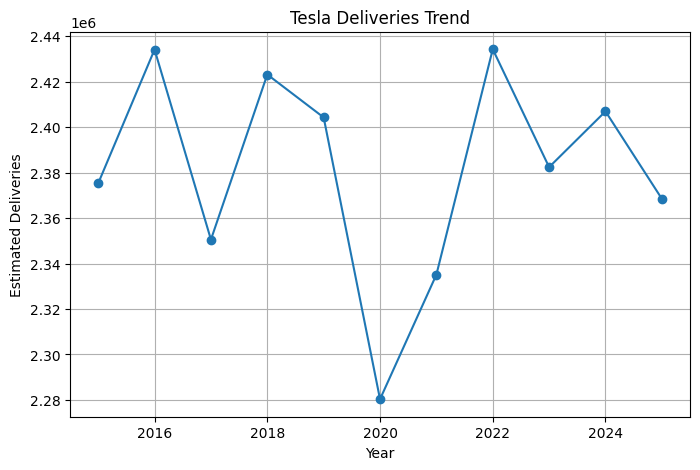

In [51]:
# Yearly Deliveries Trend
yearly = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(8,5))
plt.plot(yearly.index, yearly.values, marker='o')
plt.title("Tesla Deliveries Trend")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")
plt.grid(True)
plt.show()

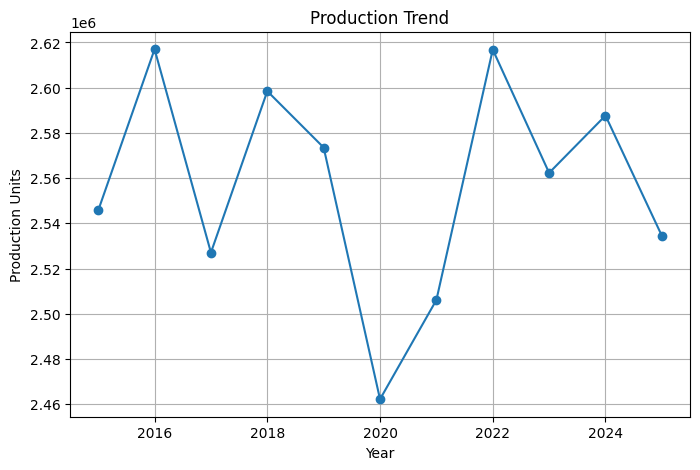

In [52]:
# Production Trend
production = df.groupby('Year')['Production_Units'].sum()

plt.figure(figsize=(8,5))
plt.plot(production.index, production.values, marker='o')
plt.title("Production Trend")
plt.xlabel("Year")
plt.ylabel("Production Units")
plt.grid(True)
plt.show()

In [53]:
# Create New Features
df['Gap'] = df['Production_Units'] - df['Estimated_Deliveries']
df['Price_per_km'] = df['Avg_Price_USD'] / df['Range_km']

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Gap,Price_per_km
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,276,131.923679
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,367,142.022032
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,778,245.598583
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,756,125.414199
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,1163,173.747020


In [54]:
# Define Features and Target
X = df.drop('Avg_Price_USD', axis=1)
y = df['Avg_Price_USD']

categorical_features = ['Region', 'Model', 'Source_Type']

for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
# Build Model Pipeline
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])


In [56]:
# Hyperparameter Tuning
params = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [5, 10, None]
}

grid = GridSearchCV(
    pipeline,
    params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'model__max_depth': None, 'model__n_estimators': 100}


In [57]:
# Model Evaluation
best_model = grid.best_estimator_
pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 639.971742613634
RMSE: 859.06308775994
R2 Score: 0.9980430536584786


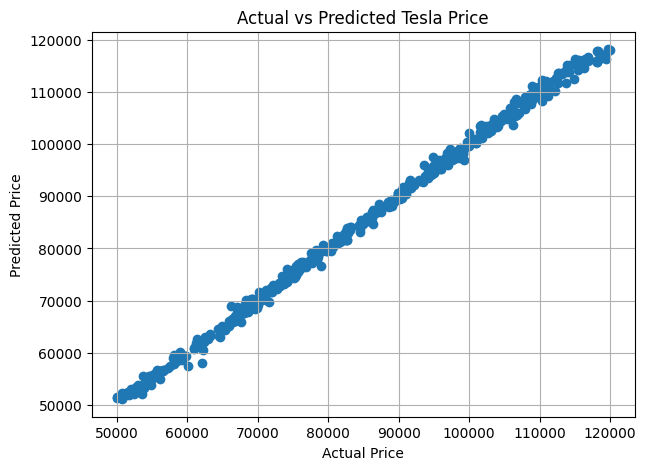

In [58]:
# Actual vs Predicted
plt.figure(figsize=(7,5))
plt.scatter(y_test, pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Tesla Price")
plt.grid(True)
plt.show()

In [59]:
# Simple Forecast Table
forecast = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()
forecast['Next_Year_Delivery'] = forecast['Estimated_Deliveries'].shift(-1)

forecast

,Year,Estimated_Deliveries,Next_Year_Delivery
0,2015,2375267,2434081.0
1,2016,2434081,2350517.0
2,2017,2350517,2423104.0
3,2018,2423104,2404230.0
4,2019,2404230,2280336.0
5,2020,2280336,2335116.0
6,2021,2335116,2434220.0
7,2022,2434220,2382375.0
8,2023,2382375,2406899.0
9,2024,2406899,2368462.0


In [60]:
# Region-wise Deliveries
region_delivery = df.groupby('Region')['Estimated_Deliveries'].sum()

print("\nRegion-wise Deliveries:")
print(region_delivery)


Region-wise Deliveries:
Region
Asia             6539935
Europe           6494035
Middle East      6698045
North America    6462592
Name: Estimated_Deliveries, dtype: int64
